# Use case: comparison of the human pathways in Reactome with momapy

In this use case, we demonstrate how momapy can be used to compare a large set of maps.
<br>We find and visualise common modulations between human pathways in Reactome using momapy.
<br>We show that these operations can be performed easily with simple Python built-ins or momapy functions.

In [1]:
import pathlib
import shutil
import itertools
import tarfile
import urllib.request
import csv

import momapy.io.core
import momapy.sbgn.utils

import utils

## Downloading the pathways

In [2]:
input_dir_path = pathlib.Path("data/")

We remake the directory where we will download the pathways:

In [3]:
if input_dir_path.exists():
    shutil.rmtree(input_dir_path)
input_dir_path.mkdir(parents=True)

We download the pathways, under the form of SBGN PD maps:

In [4]:
sbgn_archive_url = "https://download.reactome.org/95/homo_sapiens.sbgn.tar.gz"
sbgn_archive_file_path = input_dir_path / "homo_sapiens.sbgn.tar.gz"
urllib.request.urlretrieve(sbgn_archive_url, sbgn_archive_file_path)
with tarfile.open(sbgn_archive_file_path) as tar:
    tar.extractall(path=input_dir_path)

We download the list of pathways that maps pathways ids to pathways names:

In [5]:
list_of_pathways_file_path = input_dir_path / "list_of_pathways.csv"

In [6]:
list_of_pathways_url = "https://download.reactome.org/95/ReactomePathways.txt"
_ = urllib.request.urlretrieve(list_of_pathways_url, list_of_pathways_file_path)

In [7]:
pathway_id_to_name = {}

with list_of_pathways_file_path.open() as f:
    reader = csv.reader(f, delimiter="\t")
    for row in reader:
        pathway_id_to_name[row[0]] = row[1]

## Comparing the pathways with momapy

We read all pathways. We want to compare their models, so we only extract those:

In [8]:
pathway_id_to_model = {}

for file_path in input_dir_path.glob("*.sbgn"):
    model = momapy.io.core.read(file_path, return_type="model").obj
    pathway_id_to_model[file_path.stem] = model

print(f"Got {len(pathway_id_to_model)} models")

Got 1358 models


We may compare different attributes of pathways (e.g., their entities, processes, modulations).
<br>Here we decide to compare their modulations, as they are the most complex objects.
<br>The identity of a modulation is defined by its type (e.g., stimulation), its source (entity pool or logical operator) and its target (stoichiometric process or phenotype).
<br>For each couple of different pathways, we compute the Jaccard index between their sets of modulations.
<br>In momapy, all model elements are frozen dataclass instances that can be hashed based on their identity, and stored in Python sets.
<br>Hence model elements, and sets of model elements, can be easily compared using built-in Python functions (set union and intersection, ==, etc.):

In [9]:
ATTRIBUTE = "modulations"

results = {}
for (pathway_id1, model1), (pathway_id2, model2) in itertools.combinations(
    pathway_id_to_model.items(), 2
):
    set1 = getattr(model1, ATTRIBUTE)
    set2 = getattr(model2, ATTRIBUTE)
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    index = intersection / union if union > 0 else 0
    results[(pathway_id1, pathway_id2,)] = {"intersection": intersection, "index": index}

print(f"Got {len(results)} indexes")

Got 921403 indexes


We sort the results by Jaccard index, and keep only the couples of pathways that have a minimum number of common modulations:

In [10]:
MIN_INTERSECTION = 5

results = sorted(
    [item for item in results.items() if item[1]["intersection"] >= MIN_INTERSECTION],
    key=lambda item: item[1]["index"],
    reverse=True,
)

print(f"Got {len(results)} couples")

Got 41 couples


We print the 10 best results under the form "pathway1 | pathway2 | cardinality of intersection | Jaccard index":

In [11]:
for (pathway_id1, pathway_id2), scores in results[:10]:
    print("*", pathway_id_to_name[pathway_id1], "|", pathway_id_to_name[pathway_id2], "|", scores["intersection"], "|", round(scores["index"], 2))

* Signaling by NOTCH1 PEST Domain Mutants in Cancer | Signaling by NOTCH1 HD+PEST Domain Mutants in Cancer | 6 | 0.6
* Expression of BMAL (ARNTL), CLOCK, and NPAS2 | Heme signaling | 13 | 0.57
* DAG and IP3 signaling | Opioid Signalling | 20 | 0.44
* MyD88:MAL(TIRAP) cascade initiated on plasma membrane | MyD88 cascade initiated on plasma membrane | 6 | 0.3
* Signaling by NTRK1 (TRKA) | MAPK targets/ Nuclear events mediated by MAP kinases | 12 | 0.29
* Formation of the posterior neural plate | Formation of the anterior neural plate | 5 | 0.26
* DAG and IP3 signaling | Anti-inflammatory response favouring Leishmania parasite infection | 9 | 0.21
* Neddylation | KEAP1-NFE2L2 pathway | 12 | 0.2
* DAG and IP3 signaling | Activation of NMDA receptors and postsynaptic events | 9 | 0.19
* Formation of the nephric duct | Formation of intermediate mesoderm | 7 | 0.19


## Visualising the results with momapy

The second result seems to show that heme signalling is somehow related to the circadian clock, which is an interesting observation.
<br>We could print the common modulations, but since we are working with maps, we can visualise them instead.
<br>To do this, we read the pathways, this time extracting the full maps, and display the layout elements representing the common modulations.

In [12]:
pathway_id1, pathway_id2 = results[1][0]
print(f"Pathway 1: {pathway_id1} | {pathway_id_to_name[pathway_id1]}")
print(f"Pathway 2: {pathway_id2} | {pathway_id_to_name[pathway_id2]}")

Pathway 1: R-HSA-9931509 | Expression of BMAL (ARNTL), CLOCK, and NPAS2
Pathway 2: R-HSA-9707616 | Heme signaling


We extract the full maps, to have access to their layouts and layout model mappings:

In [13]:
pathway1 = momapy.io.core.read(input_dir_path / f"{pathway_id1}.sbgn").obj
pathway2 = momapy.io.core.read(input_dir_path / f"{pathway_id2}.sbgn").obj

Reactome's SBGN output can be a bit messy so we first tidy the maps:

In [14]:
pathway1 = momapy.sbgn.utils.tidy(pathway1)
pathway2 = momapy.sbgn.utils.tidy(pathway2)

We visualise the maps:

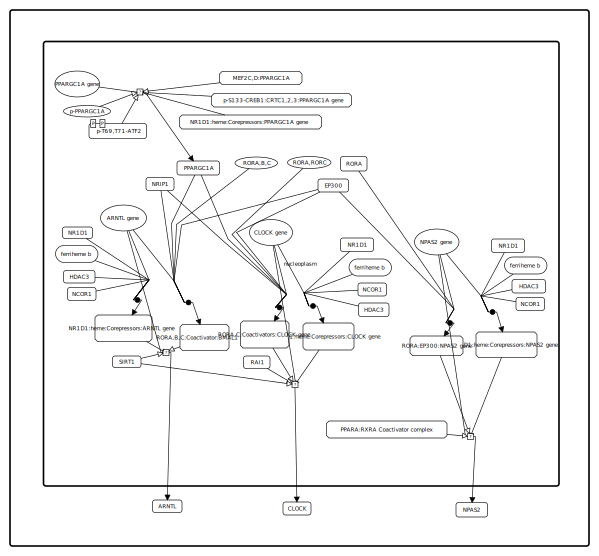

In [15]:
utils.display(pathway1, scale=0.5)

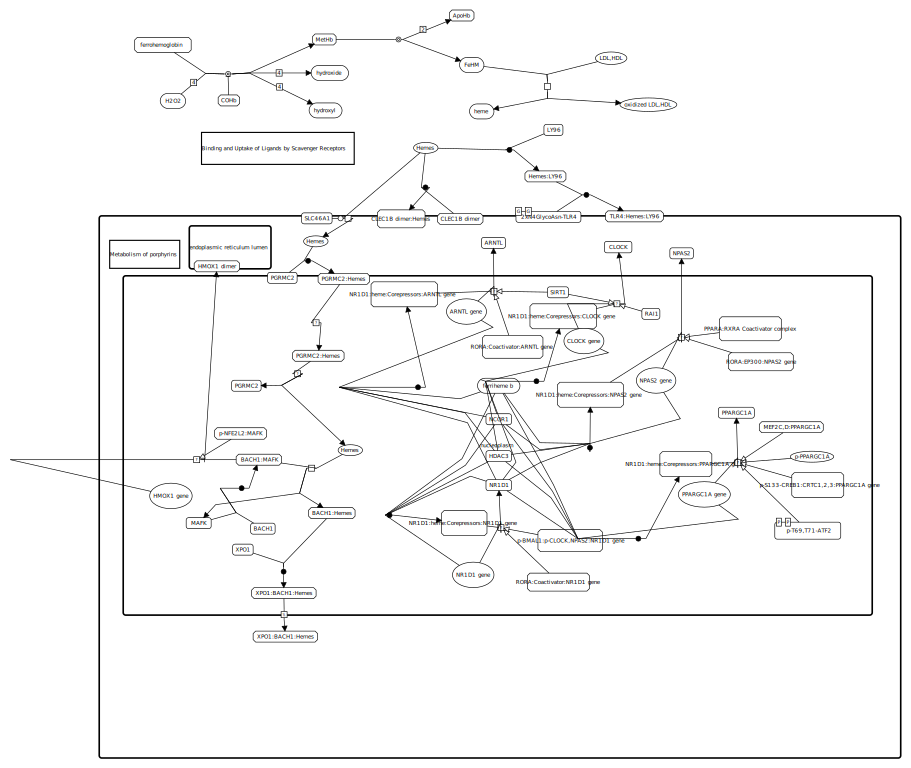

In [16]:
utils.display(pathway2, scale=0.5)

We get their common modulations once again:

In [17]:
set1 = getattr(pathway1.model, ATTRIBUTE)
set2 = getattr(pathway2.model, ATTRIBUTE)
intersection = set1.intersection(set2)

Finally, we display the layout elements that represent the common modulations, that we take from the first pathway:

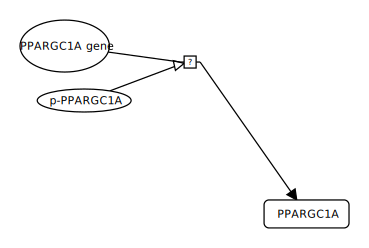

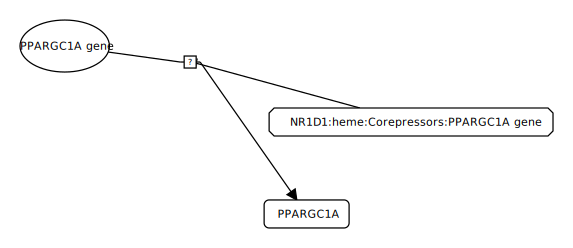

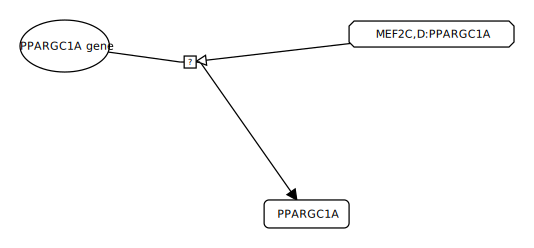

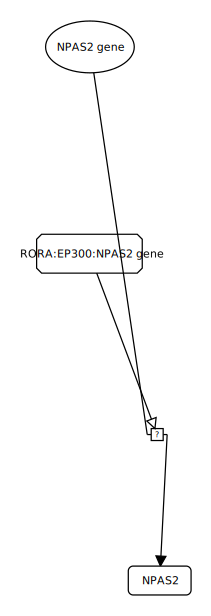

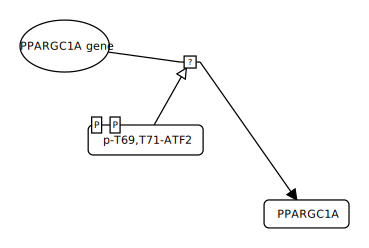

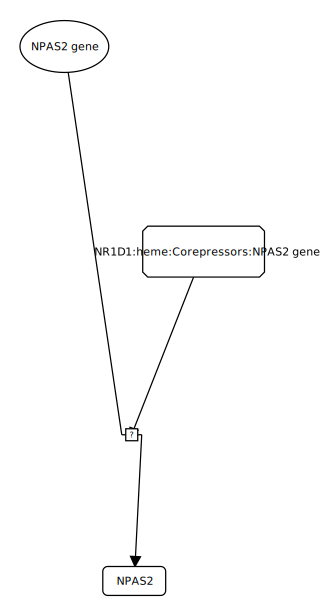

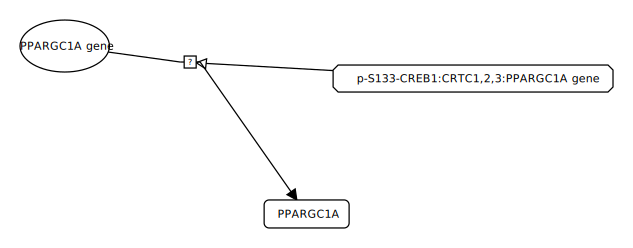

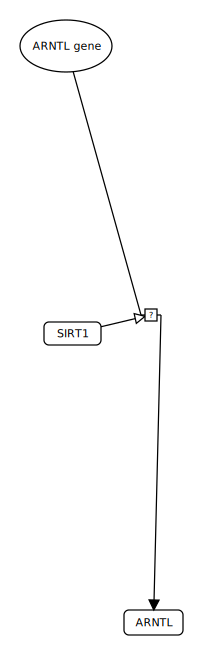

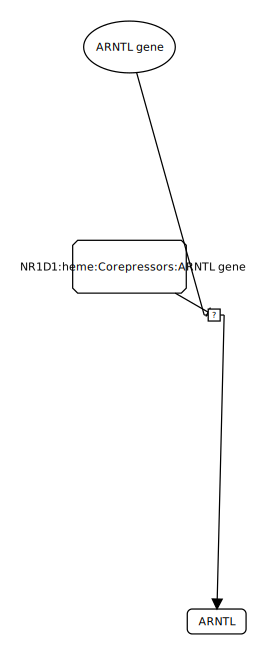

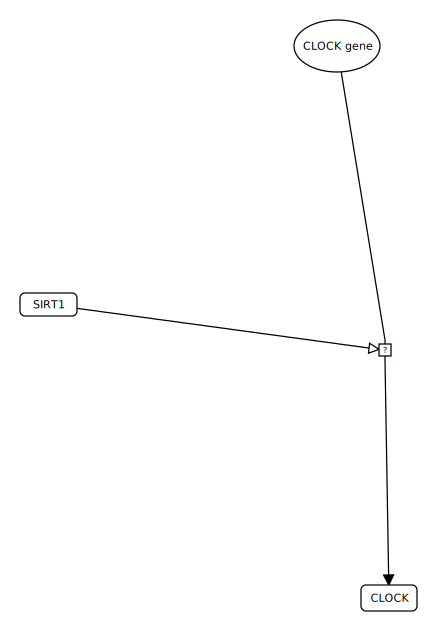

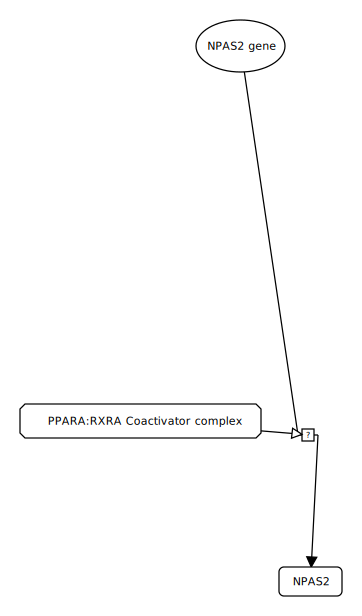

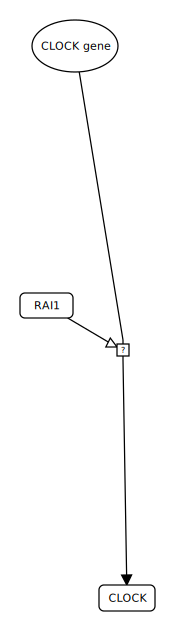

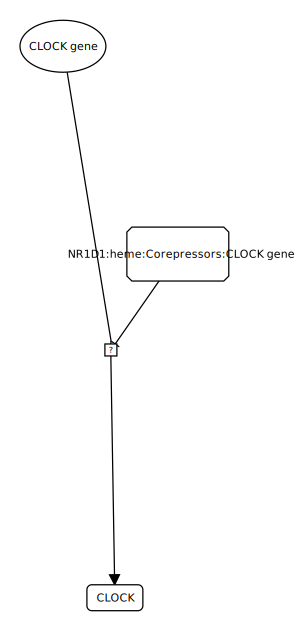

In [18]:
for model_element in intersection:
    layout_elements = pathway1.layout_model_mapping.get_mapping(model_element)[0]
    utils.display(layout_elements)